In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## First look about the data set
+ df have 9994 rows and 13 colums
+ df have no missing values, no repeat

In [8]:
df=pd.read_csv(r"..\data\raw\SampleSuperstore.csv")
#print(df.head())
#print(df.tail())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.7 MB
None
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        

## find the outliers for quantity data by IQR
+ numeric columns: ['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
+ Sales: 301 outliers (5.53%)
+ Quantity: 0 outliers (0.00%)
+ Discount: 0 outliers (0.00%)
+ Profit: 244 outliers (4.48%)


In [9]:
numCols= df.select_dtypes(include="number").columns.to_list()
print(numCols)
numCols.remove("Postal Code")
print(numCols)

def caculateIQR(col, df):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    return IQR,Q1,Q3
def caculateBound(col, df):
    IQR,Q1,Q3=caculateIQR(col,df)
    lowerBound=round(Q1-1.5*IQR,2)
    upperBound=round(Q3+1.5*IQR,2)
    return lowerBound, upperBound
for col in numCols:
    lb, up = caculateBound(col, df)
    outliers = df[(df[col] < lb) | (df[col] > up)]
    pct = len(outliers) / len(df) * 100
    print(f"{col}: {len(outliers)} outliers ({pct:.2f}%)")



['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
['Sales', 'Quantity', 'Discount', 'Profit']
Sales: 1167 outliers (11.68%)
Quantity: 170 outliers (1.70%)
Discount: 856 outliers (8.57%)
Profit: 1881 outliers (18.82%)


## look at outlier
+ sales increase when the profit is higher
+ profits go down when the discount is higher
=> so I choose not to remove these outliers

In [10]:
lb_sales, ub_sales = caculateBound("Sales", df)
outliers_sales = df[(df["Sales"] < lb_sales) | (df["Sales"] > ub_sales)]
print(outliers_sales[["Sales", "Profit", "Category", "Discount"]].sort_values("Sales", ascending=False).head(10))

lb_profit, ub_profit = caculateBound("Profit", df)
outliers_profit = df[(df["Profit"] < lb_profit) | (df["Profit"] > ub_profit)]
print(outliers_profit[["Sales", "Profit", "Category", "Discount"]].sort_values("Profit").head(10))

          Sales     Profit         Category  Discount
2697  22638.480 -1811.0784       Technology       0.5
6826  17499.950  8399.9760       Technology       0.0
8153  13999.960  6719.9808       Technology       0.0
2623  11199.968  3919.9888       Technology       0.2
4190  10499.970  5039.9856       Technology       0.0
9039   9892.740  4946.3700  Office Supplies       0.0
4098   9449.950  4630.4755  Office Supplies       0.0
4277   9099.930  2365.9818       Technology       0.0
8488   8749.950  2799.9840       Technology       0.0
6425   8399.976  1119.9968       Technology       0.4
          Sales     Profit         Category  Discount
7772   4499.985 -6599.9780       Technology       0.7
683    7999.980 -3839.9904       Technology       0.5
9774   2177.584 -3701.8928  Office Supplies       0.8
3011   2549.985 -3399.9800       Technology       0.7
4991   1889.990 -2929.4845  Office Supplies       0.8
3151   1799.994 -2639.9912       Technology       0.7
5310   1525.188 -2287.7820  

## describe numeric data
+ sales and profits have big bias

              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.857901     3.789574     0.156203    28.656599
std      623.245124     2.225110     0.206452   234.260115
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000


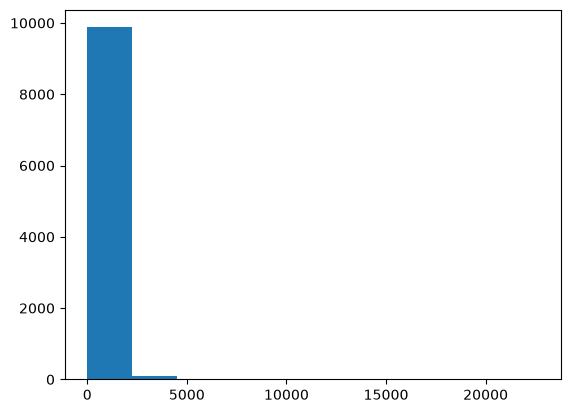

In [ ]:
describe=df[numCols].describe()
describe.to_csv("describeSuperStore.csv")
print(describe)
